In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
from itertools import groupby

from phonespam import PhoneModel


In [3]:
model = PhoneModel.from_pretrained("juice500/wavlm-24-phonemodel")

In [6]:
wav = model.load_audio("plots/LDC93S1.wav")
feats = model.extract_features(wav)
spam = model.spam_from_features(feats)  # (T, n_features), sigmoid
duration = len(wav) / model.sr

In [11]:
# TIMIT's 61-phone alphabet -> IPA, matching training/prepare_datasets.
TIMIT_TO_IPA = {
    "aa": "ɑ",
    "ae": "æ",
    "ah": "ʌ",
    "ao": "ɔ",
    "aw": "aʊ",
    "ax": "ə",
    "ax-h": "ə̥",
    "axr": "ə˞",
    "ay": "aɪ",
    "b": "b",
    "bcl": "b",
    "ch": "t͡ʃ",
    "d": "d",
    "dcl": "d",
    "dh": "ð",
    "dx": "ɾ",
    "eh": "ɛ",
    "el": "l̩",
    "em": "m̩",
    "en": "n̩",
    "eng": "ŋ̩",
    "epi": "_",
    "er": "ɜ˞",
    "ey": "eɪ",
    "f": "f",
    "g": "ɡ",
    "gcl": "ɡ",
    "h#": "_",
    "hh": "h",
    "hv": "ɦ",
    "ih": "ɪ",
    "ix": "ɨ",
    "iy": "i",
    "jh": "d͡ʒ",
    "k": "k",
    "kcl": "k",
    "l": "l",
    "m": "m",
    "n": "n",
    "ng": "ŋ",
    "nx": "ɾ̃",
    "ow": "oʊ",
    "oy": "ɔɪ",
    "p": "p",
    "pau": "_",
    "pcl": "p",
    "q": "ʔ",
    "r": "ɹ",
    "s": "s",
    "sh": "ʃ",
    "t": "t",
    "tcl": "t",
    "th": "θ",
    "uh": "ʊ",
    "uw": "u",
    "ux": "ʉ",
    "v": "v",
    "w": "w",
    "y": "j",
    "z": "z",
    "zh": "ʒ",
}
# TIMIT writes a stop as closure + release; evaluation merges them into the
# release, so the closure's start becomes the phone's start.
CLOSURES = {"pcl", "tcl", "kcl", "bcl", "dcl", "gcl"}


def load_ground_truth(phn_path):
    """Read a TIMIT .phn as merged (start, end, ipa) triples in seconds."""
    rows = []
    for line in Path(phn_path).read_text().split("\n"):
        if not line.strip():
            continue
        start, end, phn = line.split()
        rows.append([int(start) / 16000, int(end) / 16000, phn])

    merged, pending_start = [], None
    for start, end, phn in rows:
        if phn in CLOSURES:
            pending_start = start if pending_start is None else pending_start
            continue
        if pending_start is not None:
            start, pending_start = pending_start, None
        merged.append((start, end, TIMIT_TO_IPA.get(phn, phn)))
    return merged

def collapse(labels, times):
    """Collapse a per-frame label sequence into (start, end, label) runs."""
    out, i = [], 0
    for label, run in groupby(labels):
        n = len(list(run))
        out.append((times[i], times[min(i + n, len(times) - 1)], label))
        i += n
    return out


truth = load_ground_truth("plots/LDC93S1.phn")

frame_labels = model.recognize(spam, np.arange(1, len(spam)))
raw = collapse(frame_labels, np.append(spam.times, duration))

boundaries = model.segment(feats, wav)
pipe_times = np.concatenate([[0.0], model.encoder.frame_to_time(boundaries), [duration]])
pipeline = list(
    zip(pipe_times[:-1], pipe_times[1:], model.recognize(spam, boundaries), strict=True)
)

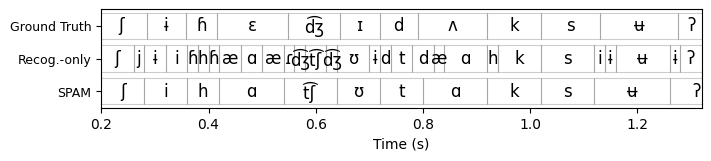

In [44]:
views = {
    "Ground Truth": truth,
    "Recog.-only": raw,
    "SPAM": pipeline,
}

fig, ax = plt.subplots(
    1, 1, figsize=(7, 1.5), sharex=True, layout="constrained"
)


low_threshold, up_threshold = 0.2, 1.32
for row, (name, segs) in enumerate(views.items()):
    for start, end, label in segs:
        midpoint = (start + end) / 2
        if low_threshold <= midpoint <= up_threshold:
            ax.add_patch(
                plt.Rectangle(
                    (start, row + 0.1),
                    max(end - start, 1e-4),
                    0.8,
                    edgecolor="black",
                    facecolor="white",
                    alpha=0.2,
                    lw=0.8,
                )
            )
            ax.text(
                midpoint, row + 0.5, label, ha="center", va="center", fontsize=12
            )
ax.set_ylim(len(views), 0)
ax.set_yticks([r + 0.5 for r in range(len(views))], list(views.keys()), fontsize=9)
ax.set_xlim(low_threshold, up_threshold)
ax.set_xlabel("Time (s)")
fig.savefig("plots/example_timit.pdf", bbox_inches="tight", pad_inches=0.0)

In [60]:
def _get_average_seglen(path):
    df = pd.read_csv(path)
    _df = df[(~df.ipa.isna()) & (df.ipa != "_")]
    return (_df["max"] - _df["min"]).mean() * 1000

_get_average_seglen("../data/timit-merged.csv"), _get_average_seglen("../data/voxangeles.csv"), 

(82.76679978036242, 131.65722895816268)